# Прогнозирование успеваемости студентов: Pass / Fail

Этот ноутбук содержит один чистый и воспроизводимый pipeline машинного обучения.

**Цель:** предсказать, получит ли студент статус `Fail (0)` или `Pass (1)`, учитывая сильный дисбаланс классов.

## Финальный workflow
1. Загрузить данные и проверить дисбаланс классов.
2. Сравнить baseline и два набора признаков.
3. Выполнить одно стратифицированное разделение Train / Validation / Test.
4. Обучить scaler только на Train.
5. Подобрать параметры Logistic Regression и Linear SVM по Validation.
6. Один раз оценить выбранные модели на Test.
7. Проанализировать confusion matrices, ложные тревоги, пропущенных студентов класса Fail, совпадение предсказаний моделей и probability threshold.
8. Указать ограничения исследования.

> **Важно:** в проекте оставлен только один последовательный pipeline. Старые варианты экспериментов с разделением 80/20 и RBF SVM не используются.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
C_VALUES = [0.01, 0.1, 1, 10]
CLASS_WEIGHTS = [None, "balanced"]

In [28]:
url = "https://huggingface.co/datasets/jason1966/algozee_student/resolve/main/student_performance_interactions.csv"
df = pd.read_csv(url)

print("Размер датасета:", df.shape)
display(df.head())
print("\nРаспределение целевой переменной:")
display(df["pass_fail"].value_counts().sort_index())
print("\nДоли классов:")
display(df["pass_fail"].value_counts(normalize=True).sort_index())

Размер датасета: (1000, 18)


,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet



Распределение целевой переменной:


,count
pass_fail,
0,70
1,930



Доли классов:


,proportion
pass_fail,
0,0.07
1,0.93


In [29]:
academic_features = [
    "previous_score",
    "math_prev_score",
    "science_prev_score",
    "language_prev_score"
]

lifestyle_features = [
    "sleep_hours",
    "screen_time_hours",
    "physical_activity_minutes"
]

academic_lifestyle_features = academic_features + lifestyle_features

In [30]:
X = df
X_academic = X[academic_features]
X_lifestyle = X[academic_lifestyle_features]

In [31]:
y = df["pass_fail"]

indices = np.arange(len(df))

idx_temp, idx_test = train_test_split(
    indices, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.17647,
    random_state=RANDOM_STATE, stratify=y.iloc[idx_temp]
)

X_academic_train = X_academic.iloc[idx_train]
X_academic_val = X_academic.iloc[idx_val]

X_lifestyle_train = X_lifestyle.iloc[idx_train]
X_lifestyle_val = X_lifestyle.iloc[idx_val]

y_train = y.iloc[idx_train]
y_val = y.iloc[idx_val]

In [32]:
scaler_academic = StandardScaler()

X_academic_train_scaled = scaler_academic.fit_transform(X_academic_train)
X_academic_val_scaled = scaler_academic.transform(X_academic_val)

In [33]:
scaler_lifestyle = StandardScaler()

X_lifestyle_train_scaled = scaler_lifestyle.fit_transform(X_lifestyle_train)
X_lifestyle_val_scaled = scaler_lifestyle.transform(X_lifestyle_val)

In [34]:
BEST_C = 1
BEST_CLASS_WEIGHT = "balanced"
lr_academic = LogisticRegression(
    C=BEST_C,
    class_weight=BEST_CLASS_WEIGHT,
    max_iter=1000
)

lr_academic.fit(X_academic_train_scaled, y_train)

y_val_academic = lr_academic.predict(X_academic_val_scaled)

In [35]:
BEST_C = 1
BEST_CLASS_WEIGHT = "balanced"
lr_lifestyle = LogisticRegression(
    C=BEST_C,
    class_weight=BEST_CLASS_WEIGHT,
    max_iter=1000
)

lr_lifestyle.fit(X_lifestyle_train_scaled, y_train)

y_val_lifestyle = lr_lifestyle.predict(X_lifestyle_val_scaled)

In [36]:
print("Academic only")
print("Accuracy:", accuracy_score(y_val, y_val_academic))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_academic))
print("Macro-F1:", f1_score(y_val, y_val_academic, average="macro"))
print("Fail Precision:", precision_score(y_val, y_val_academic, pos_label=0))
print("Fail Recall:", recall_score(y_val, y_val_academic, pos_label=0))
print("Fail F1:", f1_score(y_val, y_val_academic, pos_label=0))

Academic only
Accuracy: 0.8133333333333334
Balanced Accuracy: 0.8574231523871811
Macro-F1: 0.6527777777777778
Fail Precision: 0.2702702702702703
Fail Recall: 0.9090909090909091
Fail F1: 0.4166666666666667


In [37]:
print("Academic + Lifestyle")
print("Accuracy:", accuracy_score(y_val, y_val_lifestyle))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_lifestyle))
print("Macro-F1:", f1_score(y_val, y_val_lifestyle, average="macro"))
print("Fail Precision:", precision_score(y_val, y_val_lifestyle, pos_label=0))
print("Fail Recall:", recall_score(y_val, y_val_lifestyle, pos_label=0))
print("Fail F1:", f1_score(y_val, y_val_lifestyle, pos_label=0))

Academic + Lifestyle
Accuracy: 0.8
Balanced Accuracy: 0.8502289077828646
Macro-F1: 0.64
Fail Precision: 0.2564102564102564
Fail Recall: 0.9090909090909091
Fail F1: 0.4


In [38]:
comparison = pd.DataFrame({
    "Model": ["Academic only", "Academic + Lifestyle"],
    "Accuracy": [
        accuracy_score(y_val, y_val_academic),
        accuracy_score(y_val, y_val_lifestyle)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_val, y_val_academic),
        balanced_accuracy_score(y_val, y_val_lifestyle)
    ],
    "Macro-F1": [
        f1_score(y_val, y_val_academic, average="macro"),
        f1_score(y_val, y_val_lifestyle, average="macro")
    ],
    "Fail Precision": [
        precision_score(y_val, y_val_academic, pos_label=0),
        precision_score(y_val, y_val_lifestyle, pos_label=0)
    ],
    "Fail Recall": [
        recall_score(y_val, y_val_academic, pos_label=0),
        recall_score(y_val, y_val_lifestyle, pos_label=0)
    ],
    "Fail F1": [
        f1_score(y_val, y_val_academic, pos_label=0),
        f1_score(y_val, y_val_lifestyle, pos_label=0)
    ]
})

comparison

,Model,Accuracy,Balanced Accuracy,Macro-F1,Fail Precision,Fail Recall,Fail F1
0,Academic only,0.813333,0.857423,0.652778,0.27027,0.909091,0.416667
1,Academic + Lifestyle,0.800000,0.850229,0.640000,0.25641,0.909091,0.400000


## 1. Группы признаков и исследовательский вопрос

Вместо того чтобы удалять признаки только потому, что их много, сравниваются два набора:

- **Только академические признаки**
- **Академические + признаки образа жизни**

**Исследовательский вопрос:** помогает ли информация об образе жизни улучшить прогнозирование академического риска?

In [39]:
academic_features = [
    "previous_score",
    "math_prev_score",
    "science_prev_score",
    "language_prev_score",
    "daily_study_hours",
    "attendance_percentage",
    "homework_completion_rate",
]

lifestyle_features = [
    "sleep_hours",
    "screen_time_hours",
]

all_features = academic_features + lifestyle_features
y = df["pass_fail"]

print("Академические признаки:", academic_features)
print("Признаки образа жизни:", lifestyle_features)
print("Всего выбранных признаков:", len(all_features))

Академические признаки: ['previous_score', 'math_prev_score', 'science_prev_score', 'language_prev_score', 'daily_study_hours', 'attendance_percentage', 'homework_completion_rate']
Признаки образа жизни: ['sleep_hours', 'screen_time_hours']
Всего выбранных признаков: 9


In [40]:
# Baseline: всегда предсказывать Pass (1)
y_baseline = np.ones(len(y), dtype=int)

print("Baseline — всегда предсказывать Pass")
print("Accuracy:", round(accuracy_score(y, y_baseline), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y, y_baseline), 4))
print("Macro-F1:", round(f1_score(y, y_baseline, average="macro"), 4))
print("Fail Recall:", round(recall_score(y, y_baseline, pos_label=0, zero_division=0), 4))
print("Fail F1:", round(f1_score(y, y_baseline, pos_label=0, zero_division=0), 4))

Baseline — всегда предсказывать Pass
Accuracy: 0.93
Balanced Accuracy: 0.5
Macro-F1: 0.4819
Fail Recall: 0.0
Fail F1: 0.0


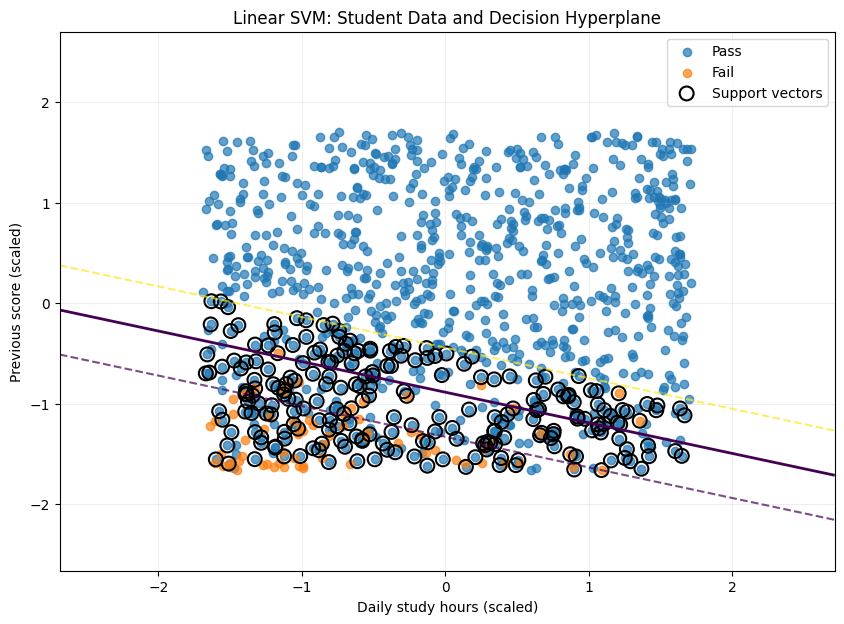

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Features for visualization
features = ["daily_study_hours", "previous_score"]

X_vis = X[features]
y_vis = y

# Split using the same training indices as in the project
X_train_vis = X_vis.iloc[idx_train]
y_train_vis = y_vis.iloc[idx_train]

# Scale features
scaler_vis = StandardScaler()
X_train_scaled = scaler_vis.fit_transform(X_train_vis)

# Train Linear SVM
svm_vis = SVC(
    kernel="linear",
    C=BEST_C,
    class_weight=BEST_CLASS_WEIGHT
)

svm_vis.fit(X_train_scaled, y_train_vis)

# Scale all points using the scaler fitted on TRAIN
X_all_scaled = scaler_vis.transform(X_vis)

# Create grid for the hyperplane
x_min = X_all_scaled[:, 0].min() - 1
x_max = X_all_scaled[:, 0].max() + 1
y_min = X_all_scaled[:, 1].min() - 1
y_max = X_all_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = svm_vis.decision_function(grid)
Z = Z.reshape(xx.shape)

# Plot all dataset points
plt.figure(figsize=(10, 7))

plt.scatter(
    X_all_scaled[y_vis == 1, 0],
    X_all_scaled[y_vis == 1, 1],
    label="Pass",
    alpha=0.7
)

plt.scatter(
    X_all_scaled[y_vis == 0, 0],
    X_all_scaled[y_vis == 0, 1],
    label="Fail",
    alpha=0.7
)

# Hyperplane
plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    linewidths=2
)

# Margin lines
plt.contour(
    xx,
    yy,
    Z,
    levels=[-1, 1],
    linestyles="--",
    alpha=0.7
)

# Support vectors
plt.scatter(
    svm_vis.support_vectors_[:, 0],
    svm_vis.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support vectors"
)

plt.xlabel("Daily study hours (scaled)")
plt.ylabel("Previous score (scaled)")
plt.title("Linear SVM: Student Data and Decision Hyperplane")
plt.legend()
plt.grid(alpha=0.2)

# Save image for GitHub README
plt.savefig(
    "svm_hyperplane.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Интерпретация baseline

Высокая `Accuracy` сама по себе может быть бесполезной для несбалансированной задачи.

Здесь baseline всегда предсказывает `Pass`, поэтому может получить высокую общую Accuracy, но при этом не находит ни одного студента класса `Fail`. Следовательно, `Fail Recall = 0`.

Именно поэтому для данной задачи необходимо смотреть не только на Accuracy, но и на `Balanced Accuracy`, `Macro-F1`, `Fail Precision`, `Fail Recall` и `Fail F1`.

## 2. Одно стратифицированное разделение Train / Validation / Test

Примерные пропорции: **70% / 15% / 15%**.

- **Train** используется для обучения моделей.
- **Validation** используется для выбора параметров моделей.
- **Test** остаётся отдельным и используется только для финальной оценки.

Test-набор не должен использоваться для выбора `C`, `class_weight` или probability threshold.

In [41]:
X_all = df[all_features]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.17647,
    random_state=RANDOM_STATE, stratify=y_temp
)

for name, target in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name}: n={len(target)}, Fail={(target == 0).sum()}, Pass={(target == 1).sum()}")

Train: n=700, Fail=49, Pass=651
Validation: n=150, Fail=11, Pass=139
Test: n=150, Fail=10, Pass=140


In [42]:
# Обучаем scaler ТОЛЬКО на Train, чтобы избежать утечки данных.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [43]:
def validation_metrics(y_true, y_pred):
    return {
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Fail Precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fail Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fail F1": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
    }

## 3. Подбор гиперпараметров по Validation

Для обеих моделей исследуются:

- `C = 0.01, 0.1, 1, 10`
- `class_weight = None / balanced`

Для сравнения используются метрики, подходящие для несбалансированной задачи.

Для SVM используется только:

`kernel="linear"`

Это соответствует линейной soft-margin SVM, рассматриваемой в проекте.

In [44]:
# Подбор параметров Logistic Regression
log_rows = []

for C in C_VALUES:
    for weight in CLASS_WEIGHTS:
        model = LogisticRegression(
            C=C,
            class_weight=weight,
            max_iter=1000,
            random_state=RANDOM_STATE
        )
        model.fit(X_train_scaled, y_train)
        row = {"C": C, "class_weight": str(weight)}
        row.update(validation_metrics(y_val, model.predict(X_val_scaled)))
        log_rows.append(row)

log_results = pd.DataFrame(log_rows).sort_values(
    ["Macro-F1", "Balanced Accuracy", "Fail F1"],
    ascending=False
).reset_index(drop=True)

display(log_results)
best_log = log_results.iloc[0]
print("Выбранная Logistic Regression:")
display(best_log.to_frame().T)

,C,class_weight,Macro-F1,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1
0,0.10,balanced,0.684635,0.910072,0.305556,1.000000,0.468085
1,1.00,None,0.684211,0.632767,0.750000,0.272727,0.400000
2,10.00,None,0.684211,0.632767,0.750000,0.272727,0.400000
3,1.00,balanced,0.680398,0.871812,0.303030,0.909091,0.454545
4,10.00,balanced,0.680398,0.871812,0.303030,0.909091,0.454545
5,0.01,balanced,0.644794,0.888489,0.261905,1.000000,0.415094
6,0.10,None,0.565972,0.545455,1.000000,0.090909,0.166667
7,0.01,None,0.480969,0.500000,0.000000,0.000000,0.000000


Выбранная Logistic Regression:


,C,class_weight,Macro-F1,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1
0,0.1,balanced,0.684635,0.910072,0.305556,1.0,0.468085


In [45]:
# Подбор параметров Linear soft-margin SVM
svm_rows = []

for C in C_VALUES:
    for weight in CLASS_WEIGHTS:
        model = SVC(
            kernel="linear",
            C=C,
            class_weight=weight
        )
        model.fit(X_train_scaled, y_train)
        row = {"C": C, "class_weight": str(weight)}
        row.update(validation_metrics(y_val, model.predict(X_val_scaled)))
        svm_rows.append(row)

svm_results = pd.DataFrame(svm_rows).sort_values(
    ["Macro-F1", "Balanced Accuracy", "Fail F1"],
    ascending=False
).reset_index(drop=True)

display(svm_results)
best_svm = svm_results.iloc[0]
print("Выбранная Linear SVM:")
display(best_svm.to_frame().T)

,C,class_weight,Macro-F1,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1
0,0.10,balanced,0.684635,0.910072,0.305556,1.000000,0.468085
1,1.00,balanced,0.673203,0.868215,0.294118,0.909091,0.444444
2,10.00,balanced,0.673203,0.868215,0.294118,0.909091,0.444444
3,0.01,balanced,0.644794,0.888489,0.261905,1.000000,0.415094
4,0.01,None,0.480969,0.500000,0.000000,0.000000,0.000000
5,0.10,None,0.480969,0.500000,0.000000,0.000000,0.000000
6,1.00,None,0.480969,0.500000,0.000000,0.000000,0.000000
7,10.00,None,0.480969,0.500000,0.000000,0.000000,0.000000


Выбранная Linear SVM:


,C,class_weight,Macro-F1,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1
0,0.1,balanced,0.684635,0.910072,0.305556,1.0,0.468085


## 4. Финальные модели и оценка на Test

Выбранные гиперпараметры фиксируются **до** просмотра результатов на Test-наборе.

После этого модели обучаются на Train и один раз оцениваются на Test.

In [46]:
final_logistic = LogisticRegression(
    C=float(best_log["C"]),
    class_weight=None if best_log["class_weight"] == "None" else "balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

final_svm = SVC(
    kernel="linear",
    C=float(best_svm["C"]),
    class_weight=None if best_svm["class_weight"] == "None" else "balanced"
)

final_logistic.fit(X_train_scaled, y_train)
final_svm.fit(X_train_scaled, y_train)

pred_logistic = final_logistic.predict(X_test_scaled)
pred_svm = final_svm.predict(X_test_scaled)

In [47]:
def evaluate_model(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    actual_fail_pred_fail = cm[0, 0]
    actual_fail_pred_pass = cm[0, 1]
    actual_pass_pred_fail = cm[1, 0]
    actual_pass_pred_pass = cm[1, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Fail Precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fail Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fail F1": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Фактически Fail → Предсказано Fail": actual_fail_pred_fail,
        "Фактически Fail → Предсказано Pass (пропущен Fail)": actual_fail_pred_pass,
        "Фактически Pass → Предсказано Fail (ложная тревога)": actual_pass_pred_fail,
        "Фактически Pass → Предсказано Pass": actual_pass_pred_pass,
    }

test_results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, pred_logistic),
    evaluate_model("Linear SVM", y_test, pred_svm),
])

display(test_results)

,Model,Accuracy,Balanced Accuracy,Macro-F1,Fail Precision,Fail Recall,Fail F1,Фактически Fail → Предсказано Fail,Фактически Fail → Предсказано Pass (пропущен Fail),Фактически Pass → Предсказано Fail (ложная тревога),Фактически Pass → Предсказано Pass
0,Logistic Regression,0.826667,0.907143,0.66621,0.277778,1.0,0.434783,10,0,26,114
1,Linear SVM,0.826667,0.907143,0.66621,0.277778,1.0,0.434783,10,0,26,114


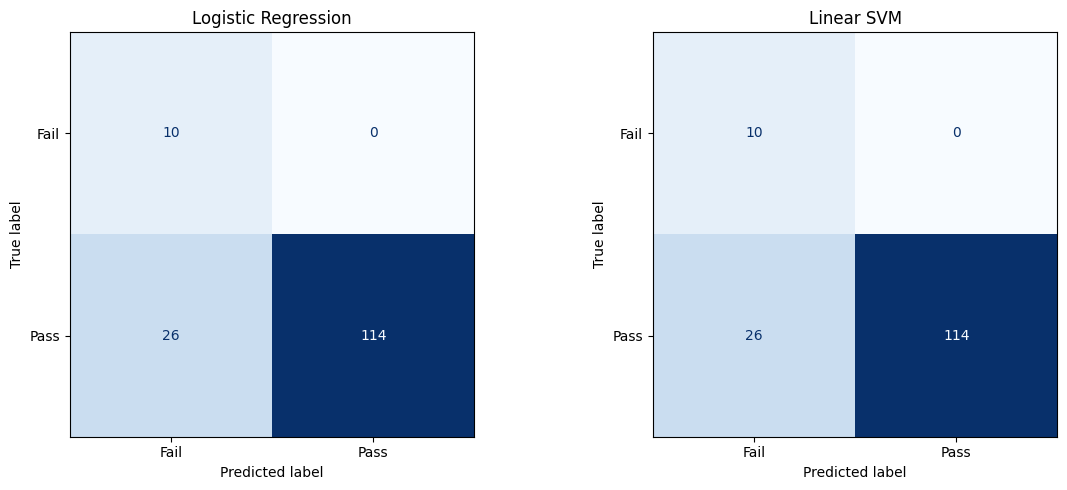

In [48]:
# Confusion matrices с понятными названиями классов вместо использования только TN/FP/FN/TP.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, pred in zip(
    axes,
    ["Logistic Regression", "Linear SVM"],
    [pred_logistic, pred_svm]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        labels=[0, 1],
        display_labels=["Fail", "Pass"],
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Интерпретация ошибок

Поскольку:

- `0 = Fail`
- `1 = Pass`

для этого проекта удобнее описывать ошибки напрямую, а не только через `TN / FP / FN / TP`.

Наиболее опасная ошибка:

**Actual Fail → Predicted Pass**

Это студент группы риска, которого модель не обнаружила.

Основная ложная тревога:

**Actual Pass → Predicted Fail**

Это студент, которого модель ошибочно отнесла к группе риска.

Поэтому одной высокой `Balanced Accuracy` недостаточно. Необходимо анализировать компромисс между:

- высоким `Fail Recall` — модель пропускает меньше студентов класса Fail;
- высоким `Fail Precision` — меньше студентов Pass ошибочно попадают в группу риска.

Например, если `Fail Recall = 1.0`, но `Fail Precision` низкий, модель может находить всех студентов группы риска, но одновременно создавать большое количество ложных тревог.

In [49]:
# Проверяем, дали ли Logistic Regression и Linear SVM одинаковые предсказания на Test.
different_predictions = np.sum(pred_logistic != pred_svm)
agreement_rate = np.mean(pred_logistic == pred_svm)

print("Количество объектов Test с разными предсказаниями:", different_predictions)
print("Доля совпадающих предсказаний:", round(agreement_rate, 4))

if different_predictions == 0:
    print("Две модели дали полностью одинаковые предсказания на Test-наборе.")
    print("Для этих масштабированных признаков и выбранных гиперпараметров их линейные границы решений")
    print("дали одинаковые метки классов для каждого объекта Test.")
else:
    comparison = pd.DataFrame({
        "Истинный класс": y_test.to_numpy(),
        "Предсказание Logistic Regression": pred_logistic,
        "Предсказание SVM": pred_svm
    })
    display(comparison[comparison["Предсказание Logistic Regression"] != comparison["Предсказание SVM"]])

Количество объектов Test с разными предсказаниями: 4
Доля совпадающих предсказаний: 0.9733


,Истинный класс,Предсказание Logistic Regression,Предсказание SVM
26,1,1,0
38,1,1,0
100,1,0,1
144,1,0,1


## 5. Только академические признаки vs Академические + признаки образа жизни

Для честного сравнения используются одинаковые индексы Train / Validation / Test для обоих наборов признаков.

Сравнение выполняется с помощью Logistic Regression с `class_weight="balanced"` как контролируемый эксперимент.

Таким образом проверяется исследовательский вопрос:

**Добавляет ли информация об образе жизни полезную информацию для прогнозирования академического риска?**

In [50]:
# Восстанавливаем те же разделения данных с помощью индексов строк.
indices = np.arange(len(df))

idx_temp, idx_test = train_test_split(
    indices, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.17647, random_state=RANDOM_STATE, stratify=y.iloc[idx_temp]
)

def compare_feature_set(feature_list, name):
    X = df[feature_list]
    scaler_fs = StandardScaler()

    Xtr = scaler_fs.fit_transform(X.iloc[idx_train])
    Xv = scaler_fs.transform(X.iloc[idx_val])
    Xte = scaler_fs.transform(X.iloc[idx_test])

    model = LogisticRegression(
        C=1,
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    )
    model.fit(Xtr, y.iloc[idx_train])
    pred = model.predict(Xte)

    row = {"Набор признаков": name, "Количество признаков": len(feature_list)}
    row.update(validation_metrics(y.iloc[idx_test], pred))
    return row

feature_results = pd.DataFrame([
    compare_feature_set(academic_features, "Только академические"),
    compare_feature_set(all_features, "Академические + образ жизни")
])

display(feature_results)

print("Интерпретация: если второй вариант улучшает метрики класса меньшинства,")
print("информация об образе жизни добавляет предсказательную ценность; иначе более простой академический набор может быть предпочтительнее.")

,Набор признаков,Количество признаков,Macro-F1,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1
0,Только академические,7,0.687811,0.917857,0.303030,1.0,0.465116
1,Академические + образ жизни,9,0.680398,0.914286,0.294118,1.0,0.454545


Интерпретация: если второй вариант улучшает метрики класса меньшинства,
информация об образе жизни добавляет предсказательную ценность; иначе более простой академический набор может быть предпочтительнее.


## 6. Эксперимент с probability threshold для Logistic Regression

`class_weight="balanced"` изменяет поведение модели, но также можно изменить порог принятия решения.

Сначала порог выбирается по **Validation set**, а затем его результат оценивается на Test.

- Более низкий threshold → обычно выше `Fail Recall`, но больше ложных тревог.
- Более высокий threshold → обычно выше `Fail Precision`, но больше риск пропустить студентов класса Fail.

Этот эксперимент позволяет явно исследовать компромисс между `Fail Precision` и `Fail Recall`, а не просто принимать стандартное правило классификации как окончательное решение.

In [51]:
# Вероятность Fail находится в столбце, соответствующем классу 0.
val_fail_proba = final_logistic.predict_proba(X_val_scaled)[:, list(final_logistic.classes_).index(0)]

thresholds = np.arange(0.05, 0.96, 0.05)
threshold_rows = []

for threshold in thresholds:
    # Предсказываем Fail (0), когда P(Fail) >= threshold.
    val_pred = np.where(val_fail_proba >= threshold, 0, 1)
    row = {"Threshold": round(float(threshold), 2)}
    row.update(validation_metrics(y_val, val_pred))
    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results)

# Choose threshold by best Validation Fail F1, then Balanced Accuracy.
best_threshold_row = threshold_results.sort_values(
    ["Fail F1", "Balanced Accuracy", "Fail Recall"],
    ascending=False
).iloc[0]

best_threshold = float(best_threshold_row["Threshold"])
print("Выбранный threshold по Validation:", best_threshold)
display(best_threshold_row.to_frame().T)

,Threshold,Macro-F1,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1
0,0.05,0.501099,0.787770,0.157143,1.000000,0.271605
1,0.10,0.547943,0.823741,0.183333,1.000000,0.309859
2,0.15,0.562627,0.834532,0.192982,1.000000,0.323529
3,0.20,0.577741,0.845324,0.203704,1.000000,0.338462
4,0.25,0.604167,0.863309,0.224490,1.000000,0.366667
5,0.30,0.620966,0.874101,0.239130,1.000000,0.385965
6,0.35,0.644794,0.888489,0.261905,1.000000,0.415094
7,0.40,0.644794,0.888489,0.261905,1.000000,0.415094
8,0.45,0.657453,0.895683,0.275000,1.000000,0.431373
9,0.50,0.684635,0.910072,0.305556,1.000000,0.468085


Выбранный threshold по Validation: 0.7


,Threshold,Macro-F1,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1
13,0.7,0.814815,0.922171,0.526316,0.909091,0.666667


In [52]:
test_fail_proba = final_logistic.predict_proba(X_test_scaled)[:, list(final_logistic.classes_).index(0)]

threshold_pred = np.where(test_fail_proba >= best_threshold, 0, 1)

threshold_test_result = pd.DataFrame([
    evaluate_model(
        f"Logistic Regression, threshold={best_threshold:.2f}",
        y_test,
        threshold_pred
    )
])

display(threshold_test_result)

print("Сравните эту строку с результатом модели при стандартном правиле классификации выше.")
print("Эксперимент с threshold явно показывает компромисс между Precision и Recall, а не принимает одно стандартное правило решения как окончательное.")

,Model,Accuracy,Balanced Accuracy,Macro-F1,Fail Precision,Fail Recall,Fail F1,Фактически Fail → Предсказано Fail,Фактически Fail → Предсказано Pass (пропущен Fail),Фактически Pass → Предсказано Fail (ложная тревога),Фактически Pass → Предсказано Pass
0,"Logistic Regression, threshold=0.70",0.886667,0.892857,0.725067,0.36,0.9,0.514286,9,1,16,124


Сравните эту строку с результатом модели при стандартном правиле классификации выше.
Эксперимент с threshold явно показывает компромисс между Precision и Recall, а не принимает одно стандартное правило решения как окончательное.


## 7. Итоговые выводы и ограничения

### Основные выводы

- Общая `Accuracy` может быть вводящей в заблуждение для несбалансированного датасета.
- Baseline `Always predict Pass` может иметь высокую Accuracy, но при этом находить **0 студентов класса Fail**.
- Модели с balancing могут снизить общую Accuracy, но значительно улучшить `Fail Recall`.
- Высокий `Fail Recall` при низком `Fail Precision` означает, что модель находит больше студентов группы риска, но одновременно создаёт много ложных тревог.
- Logistic Regression и Linear SVM необходимо сравнивать не только по итоговым метрикам, но и по количеству объектов, для которых они дают разные предсказания.
- Сравнение `Academic only` и `Academic + lifestyle` превращает feature selection в полноценный исследовательский эксперимент.
- Probability threshold даёт дополнительный способ регулировать компромисс между пропущенными студентами класса Fail и ложными тревогами.

### Ограничения проекта

- Во всём датасете около 70 примеров класса Fail.
- После разделения данных в Validation и Test остаётся примерно по 10–11 студентов класса Fail.
- Поэтому выбор гиперпараметров на одном Validation split может быть нестабильным.
- Более сильная версия проекта должна использовать **Stratified 5-Fold Cross-Validation** для выбора гиперпараметров, после чего должна выполняться одна финальная оценка на отдельном Test-наборе.
- Результаты относятся к данному конкретному датасету и выбранным признакам. Без внешней проверки их нельзя автоматически переносить на другие данные.